# Deconvolution 1.1 - Analysis

## Introduction

Here the analysis of the deconvolution results from lung samples is performed.

## Libraries

In [1]:
library(here)
library(glue)
library(tidyverse)
library(patchwork)
library(Seurat)
library(SingleCellExperiment)
library(SpatialExperiment)
library(HDF5Array)
library(scater)
library(scran)
library(ggspavis)
library(SPOTlight)
library(NMF)
library(svglite)

here() starts at /home/groups/singlecell/cvicente/SP-COVID/visium/1-deconvolution

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dp

## Load data

In [2]:
ref <- loadHDF5SummarizedExperiment("out/ref_downsampled_ln")
ref

spe <- loadHDF5SummarizedExperiment(dir = "~/SP-COVID/visium/0-processing/out/3-annot_ln_spe")
rownames(spatialCoords(spe)) <- paste(colData(spe)$cond_tissue, rownames(spatialCoords(spe)), sep = "_")
colnames(spe) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")
rowData(spe)$ensembl <- rownames(spe)
rownames(spe) <- rowData(spe)$gene_name
spe

res <- "out/deconvolution_results_ln.rds" %>%
    glue::glue() %>%
    here::here() %>%
  readRDS(.)

class: SingleCellExperiment 
dim: 970 1700 
metadata(3): ths ths ths
assays(2): counts logcounts
rownames(970): AATK ABL1 ... ZBTB16 ZFP36
rowData names(6): epi tcs ... mye all
colnames(1700): S2.c_1_29_1751 S2.c_1_95_494 ... S1.c_1_55_8017
  S1.c_1_111_4721
colData names(77): fov Area ... label marker_score
reducedDimNames(0):
mainExpName: NULL
altExpNames(3): Negative SystemControl COMMOT

class: SpatialExperiment 
dim: 30426 11641 
metadata(0):
assays(2): counts logcounts
rownames(30426): AL627309.1 AL627309.5 ... SCoV2_ORF10 SCoV2_UTR3
rowData names(6): symbol subsets_mito ... gene_name ensembl
colnames(11641): control_case_2-lymph-node_AAACAAGTATCTCCCA-1
  control_case_2-lymph-node_AAACAATCTACTAGCA-1 ...
  prolonged_case_5-lymph-node_TTGTTTCACATCCAGG-1
  prolonged_case_5-lymph-node_TTGTTTGTGTAAATTC-1
colData names(39): in_tissue array_row ... lisi_study_id annotation
reducedDimNames(3): PCA UMAP HARMONY
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

In [3]:
mod <- res$NMF
head(mat <- res$mat)[, seq_len(5)]

,Bd,Bl,Bm,Bn,DCc
control_case_2-lymph-node_AAACAAGTATCTCCCA-1,0.044452243,0.08915722,0.00000000,0.000000000,0.00000000
control_case_2-lymph-node_AAACAATCTACTAGCA-1,0.057742007,0.05092187,0.04394219,0.000000000,0.01449162
control_case_2-lymph-node_AAACACCAATAACTGC-1,0.017205912,0.00000000,0.00000000,0.000000000,0.00000000
control_case_2-lymph-node_AAACAGAGCGACTCCT-1,0.053548881,0.04498915,0.00000000,0.000000000,0.00000000
control_case_2-lymph-node_AAACAGCTTTCAGAAG-1,0.001305777,0.08347352,0.00000000,0.059100347,0.01166745
control_case_2-lymph-node_AAACAGGGTCTATATT-1,0.008041088,0.00000000,0.03197616,0.002477482,0.01966202


## Visualization

Prior to visualization, deconvolution weights from `SPOTlight` will be filtered using an adaptive minimum proportion threshold of approximately **~10%**. Specifically, any cell type weight below this threshold in a given spot will be set to zero. This step is necessary because NMF-based deconvolution methods tend to assign small non-zero weights to nearly all cell types in every spot, even when those cell types are unlikely to be truly present.

The threshold is determined by identifying the maximum value that ensures no spot becomes empty after filtering. This is calculated as the minimum of the maximum weights across all spots (`threshold <- min(apply(mat, 1, max))`). After filtering, weights in each spot are renormalized to sum to 1 (`mat_filtered <- sweep(mat_filtered, 1, rowSums(mat_filtered), /)`), ensuring they still represent valid proportions while removing spurious low-confidence assignments.


### Topic profiles

We first take a look at the Topic profiles to evaluate how specific each topic signature is for each cell identity. Ideally each cell identity will have a unique topic profile associated to it.

In [6]:
palette <- c("Bd" = "#DFF1F3", "Bl" = "#86CBD7", "Bm" = "#4E98A5", "Bn" = "#196771", "PC" = "#183A77",
             "Tc" = "#FF3071", "Th" = "#E87FD8", "ILC" = "#FCBCD3",
             "macro" = "#83E3A2", "mono" = "#4C9465", "mast" = "#2D5C40", "gran" = "#42DC41", 
             "DCc" = "#D9FE17", "DCp" = "#C4E61C",
             "EC" = "#FF7A54", "FRC" = "#A48B72", "FDC" = "#774411")

labels <- c("PC" = "PCs", "Bn" = "Naive B cells", "Bm" = "Memory B cells", "Bl" = "GCBCs light zone",
            "Bd" = "GCBCs dark zone", "Th" = "Helper T cells", "Tc" = "Cytotoxic T cells", "ILC" = "ILCs",
            "EC" = "ECs", "FDC" = "FDCs", "FRC" = "FRCs", "macro" = "Macrophages", "mono" = "Monocytes",
            "mast" = "Mast cells", "gran" = "Granulocytes", "DCc" = "Conventional DCs", "DCp" = "Plasmacytoid DCs")
ct <- names(palette)

row_maxes <- apply(mat, 1, max)
threshold <- min(row_maxes)
threshold
mat_filtered <- mat
mat_filtered[mat_filtered < threshold] <- 0
mat_filtered <- sweep(mat_filtered, 1, rowSums(mat_filtered), `/`)
sum(rowSums(mat_filtered) == 0)  

[1] 0.09836352

[1] 0

Saving 6.67 x 6.67 in image


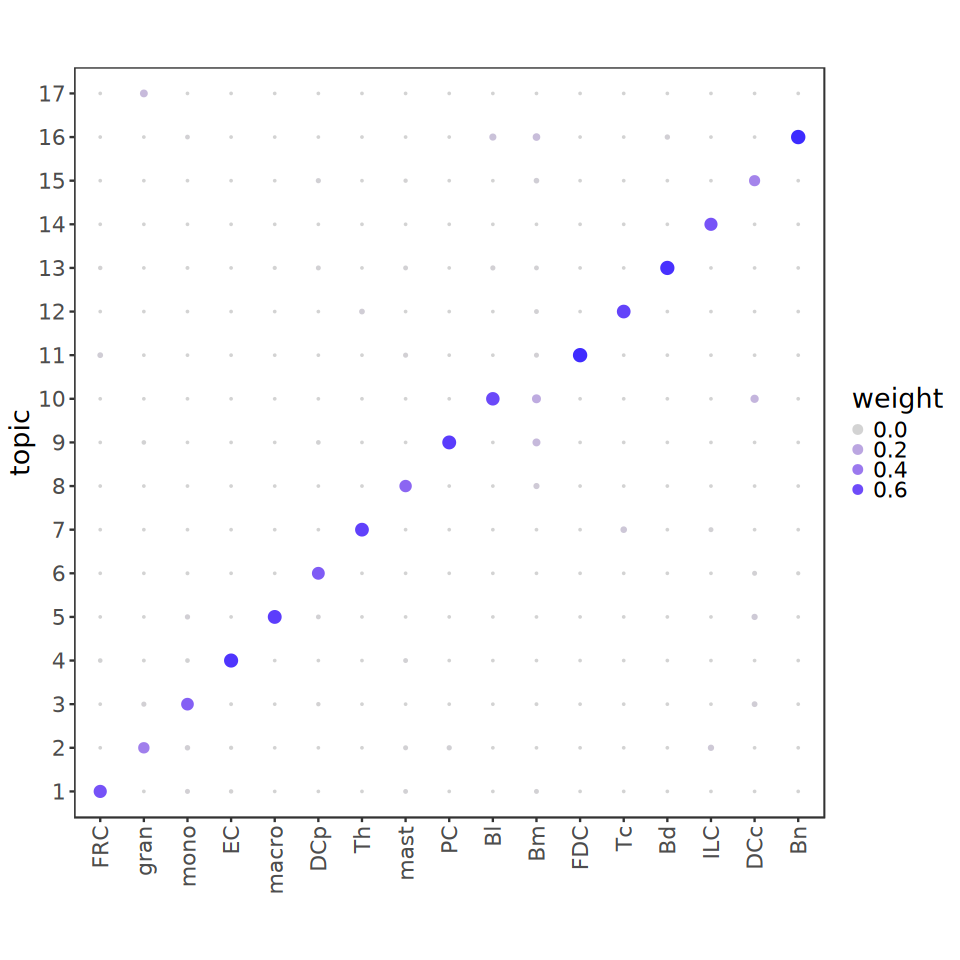

In [5]:
options(repr.plot.width = 8, repr.plot.height = 8, warn = -1)

p <- plotTopicProfiles(x = mod,
                  y = ref$lv1,
                  facet = FALSE,
                  min_prop = 0.01,
                  ncol = 1) +
theme(text = element_text(size = 16), 
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
      aspect.ratio = 1)

ct_order <- p$data %>%
    group_by(group) %>%
    slice_max(weight, n = 1) %>%         
    ungroup() %>%
    arrange(topic, desc(weight)) %>%    
    pull(group) %>%
    as.character()
p$data$group <- factor(p$data$group, levels = ct_order)
p <- p + 
    scale_x_discrete(limits = ct_order) +
    theme(text = element_text(size = 16),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
          aspect.ratio = 1)

ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/topic_profiles_ln.svg", plot = p, device = svglite)
print(p)

Next we also want to ensure that all the cells from the same cell identity share a similar topic profile since this will mean that SPOTlight has learned a consistent signature for all the cells from the same cell identity.

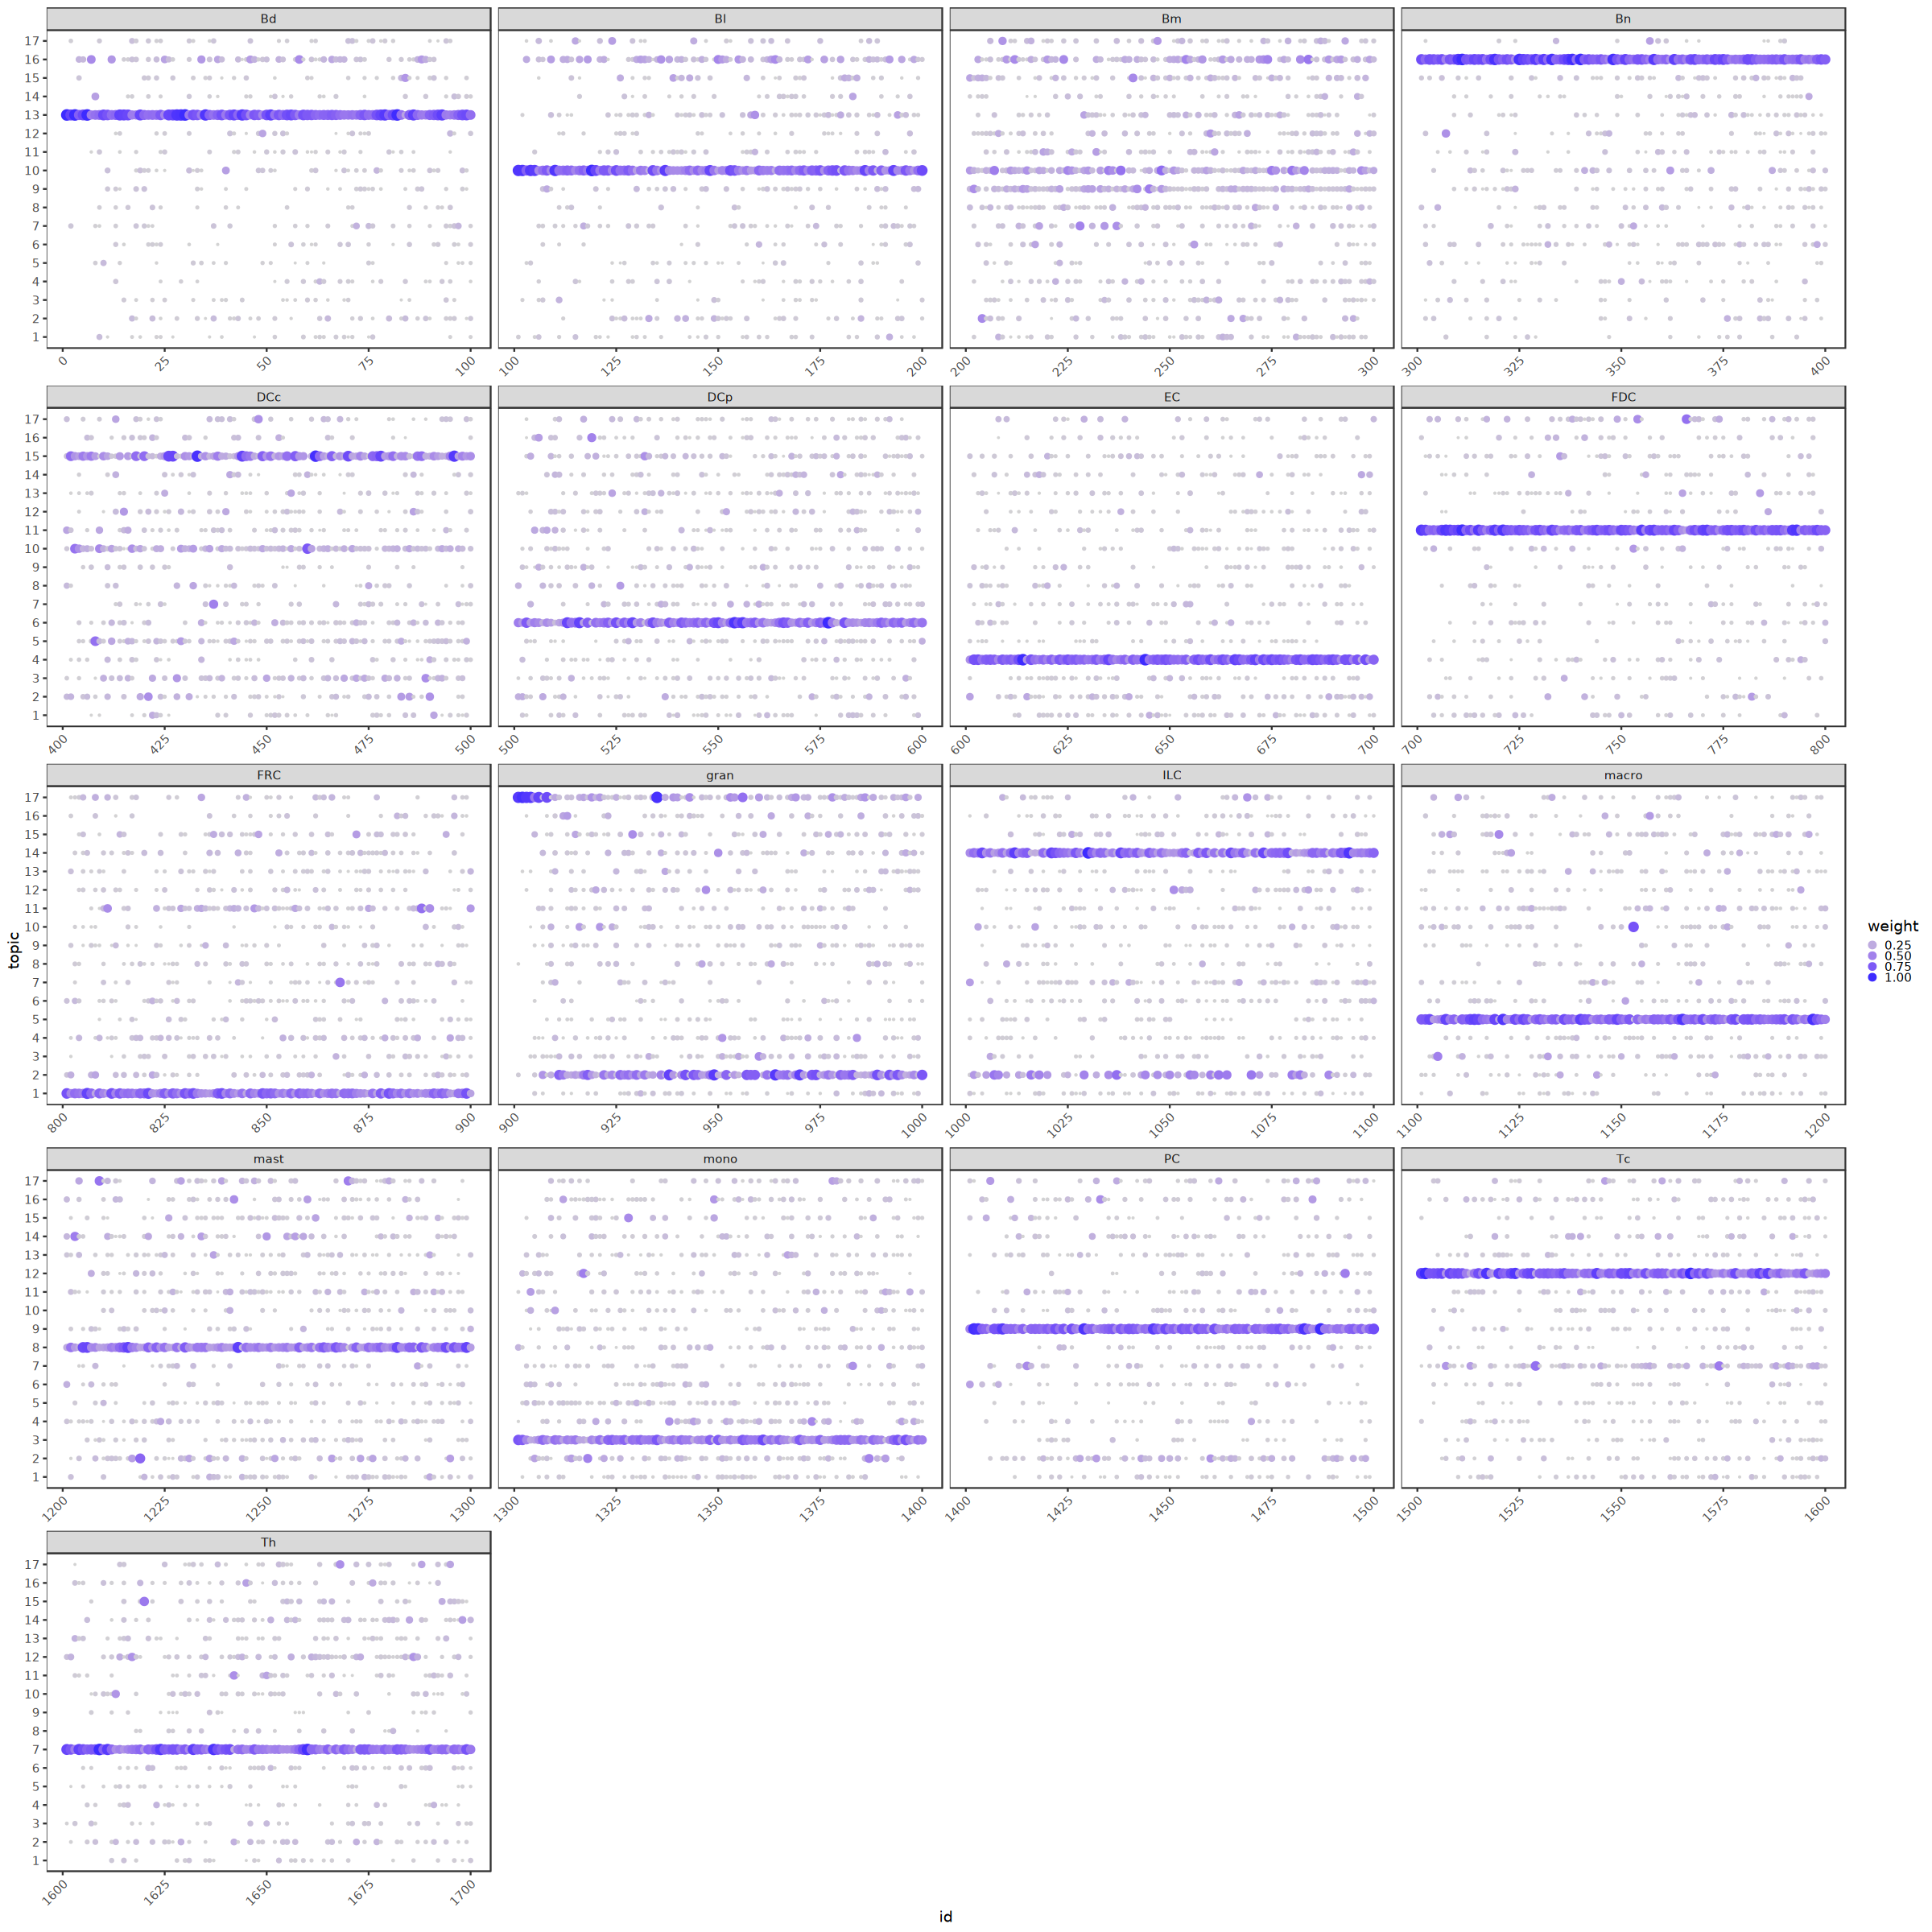

In [6]:
options(repr.plot.width = 20, repr.plot.height = 20, warn = -1)

plotTopicProfiles(x = mod,
                  y = ref$lv1,
                  facet = TRUE,
                  min_prop = 0.01,
                  ncol = 4)

Lastly we can take a look at which genes the model learned for each topic. Higher values indicate that the gene is more relevant for that topic. 

In [7]:
DT::datatable(mod$w, fillContainer = TRUE, filter = "top")

HTML widgets cannot be represented in plain text (need html)

## Residuals

We can also take a look at how well the model predicted the proportions for each spot. 
The spatial distribution of deconvolution model fit can be assessed by visualizing the residuals of the sum of squares (SS) per spot. For each spot, the SS residual quantifies the amount of biological signal in the gene expression profile that could not be explained by the predicted cell type proportions. Low residual values (close to 0) indicate that the model successfully captured the transcriptional composition of that spot, while higher values suggest the presence of biological signal not accounted for by the reference cell types. 

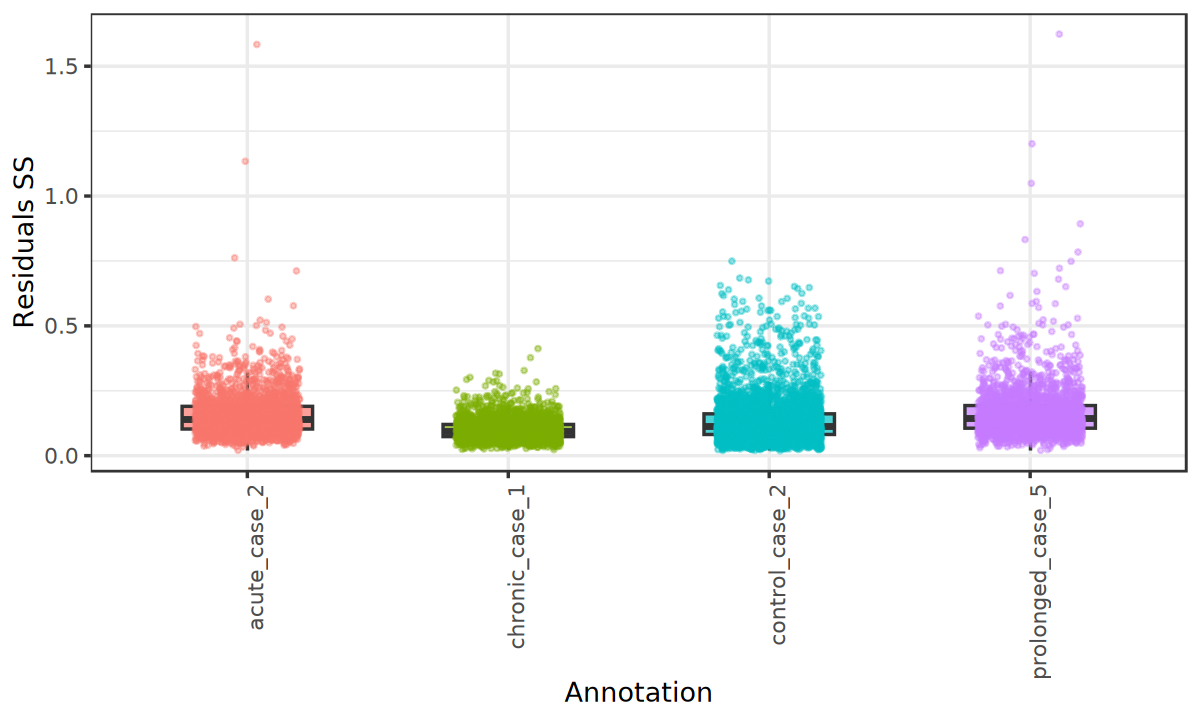

In [8]:
options(repr.plot.width = 10, repr.plot.height = 6, warn = -1)

df <- data.frame(residuals = res[[2]][colnames(spe)],
                 annotation = spe$study_id)

ggplot(df, aes(x = annotation, y = residuals, fill = annotation)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, width = 0.5) +
  geom_jitter(aes(color = annotation), width = 0.2, size = 0.8, alpha = 0.4) +
  labs(x = "Annotation", y = "Residuals SS" ) +
  theme_bw(base_size = 16) +
  theme( axis.text.x  = element_text(angle = 90, hjust = 1),
        legend.position = "none")

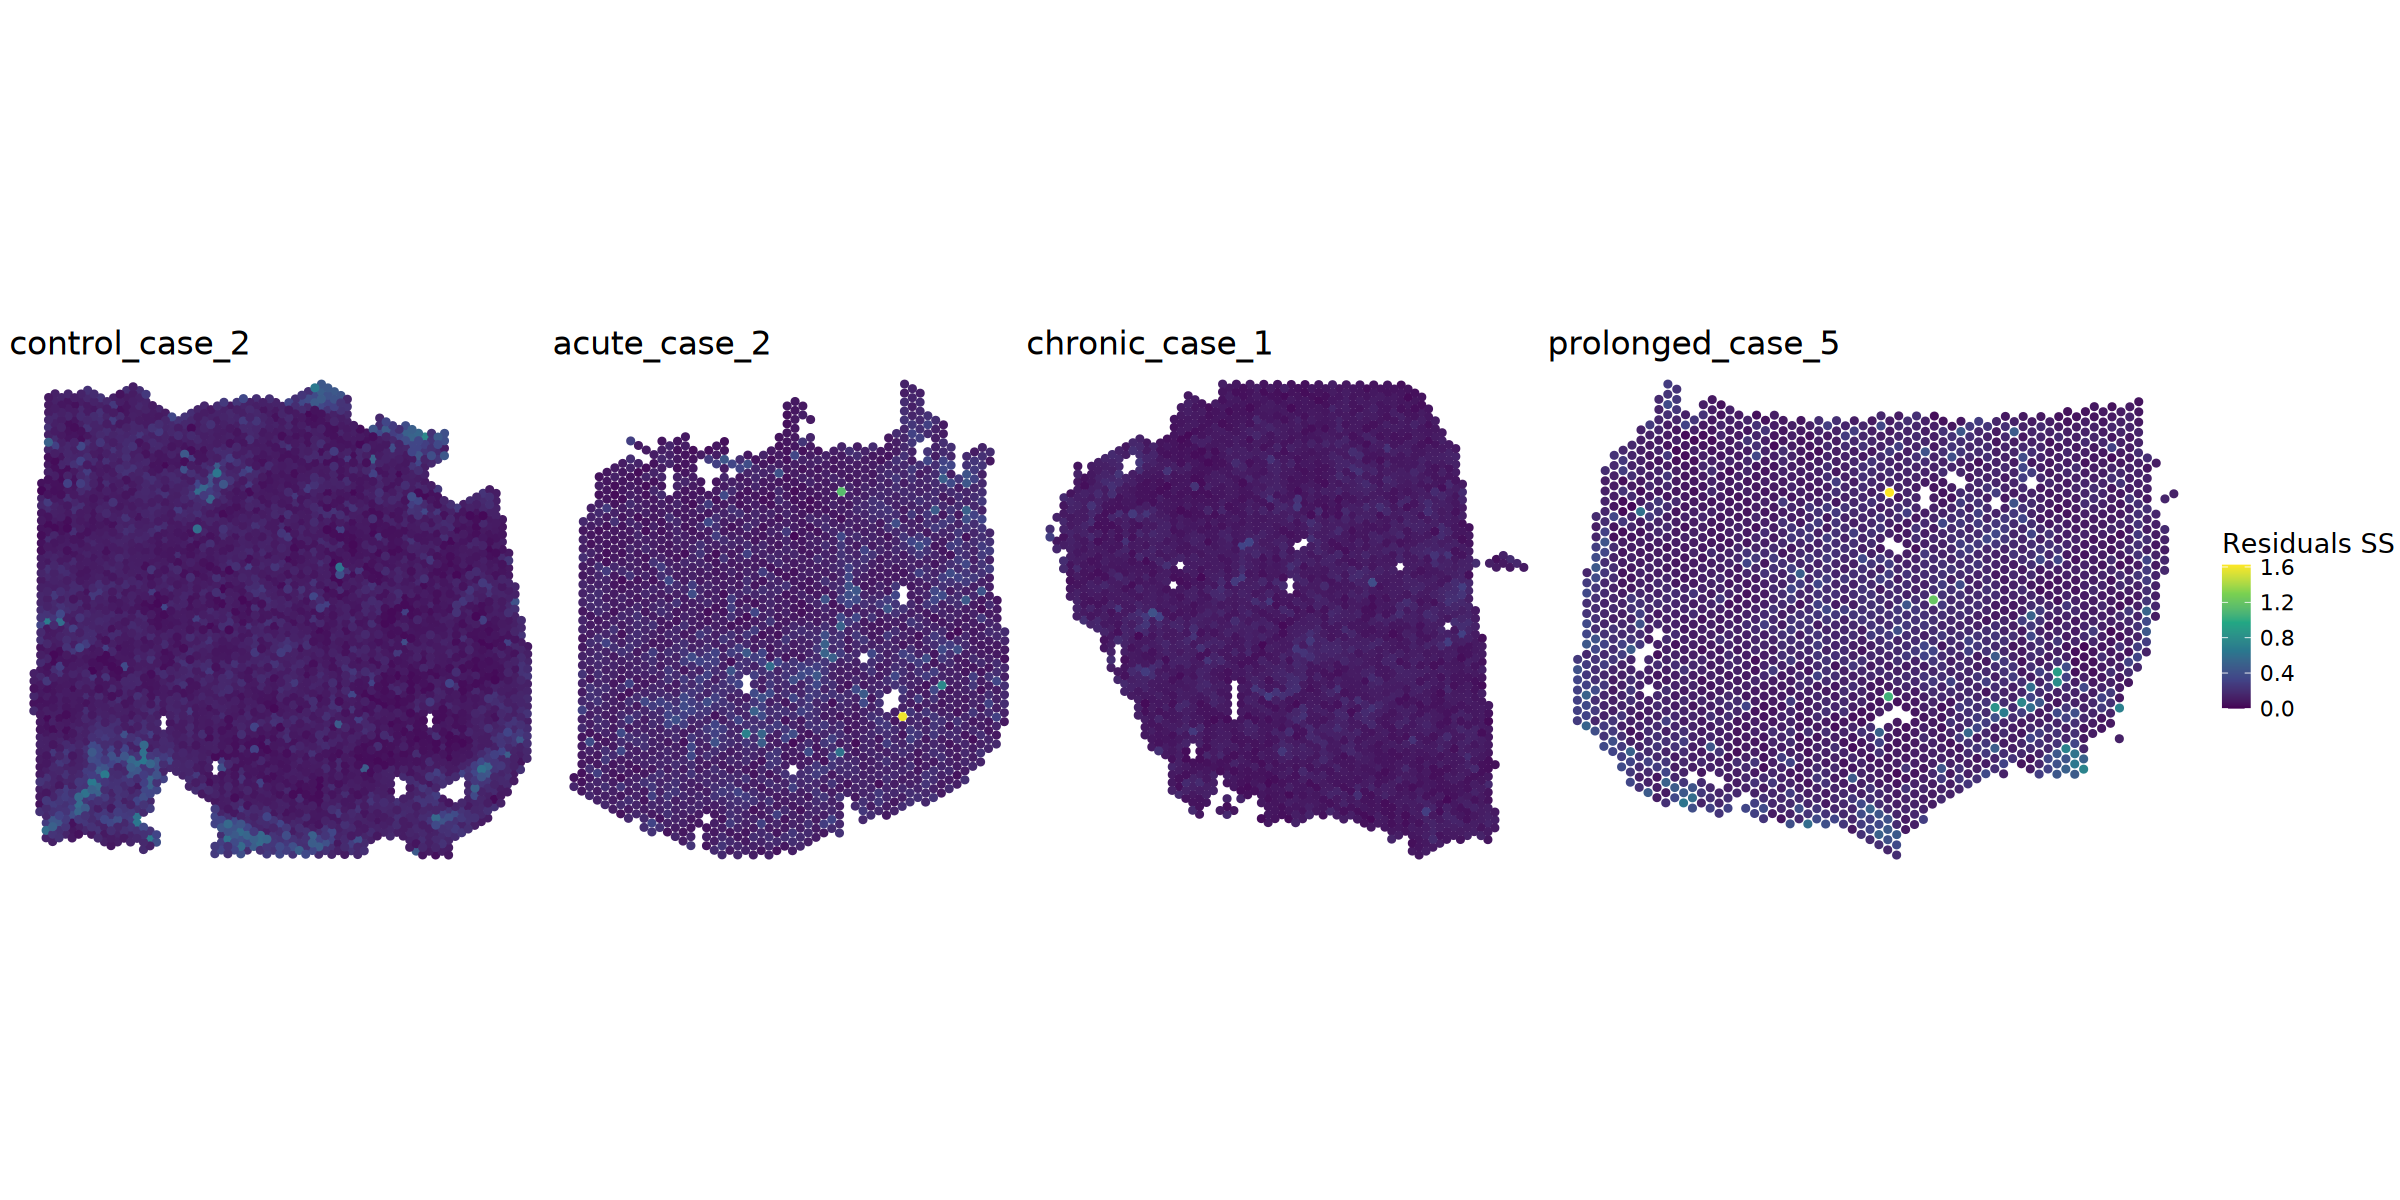

In [9]:
options(repr.plot.width = 20, repr.plot.height = 10, warn = -1)

lapply(unique(spe$study_id), function(id) {
    sub_spe <- spe[, spe$study_id == id]
    sub_spe$res_ss <- res[[2]][colnames(sub_spe)]
  
    xy <- spatialCoords(sub_spe)
    sub_spe$x <- xy[, 1]
    sub_spe$y <- xy[, 2]
  
    ggcells(sub_spe, aes(x, y, color = res_ss)) +
        geom_point() +                          
        scale_color_viridis_c(name = "Residuals SS",
                              limits = c(0, max(res[[2]])),                           
                              oob = scales::squish) +
        coord_fixed() +
        theme_void() +
        ggtitle(id) + 
        theme(text = element_text(size = 16), legend.position = "right")
}) %>%
wrap_plots(byrow = FALSE, nrow = 1) + 
    plot_layout(guides = "collect") 

### Spatial correlation matrix

To explore the spatial co-occurrence of cell types across tissue spots, pairwise Pearson correlations between cell type proportion estimates can be computed and visualized as a heatmap. Positive correlations (orange) indicate cell types that tend to co-localize within the same spots, suggesting shared spatial niches or functional associations. Negative correlations (blue) indicate mutually exclusive distributions, where the presence of one cell type is associated with the absence of another.

This function takes in a matrix with the predicted proportions for each spot and returns a correlation matrix between cell types.

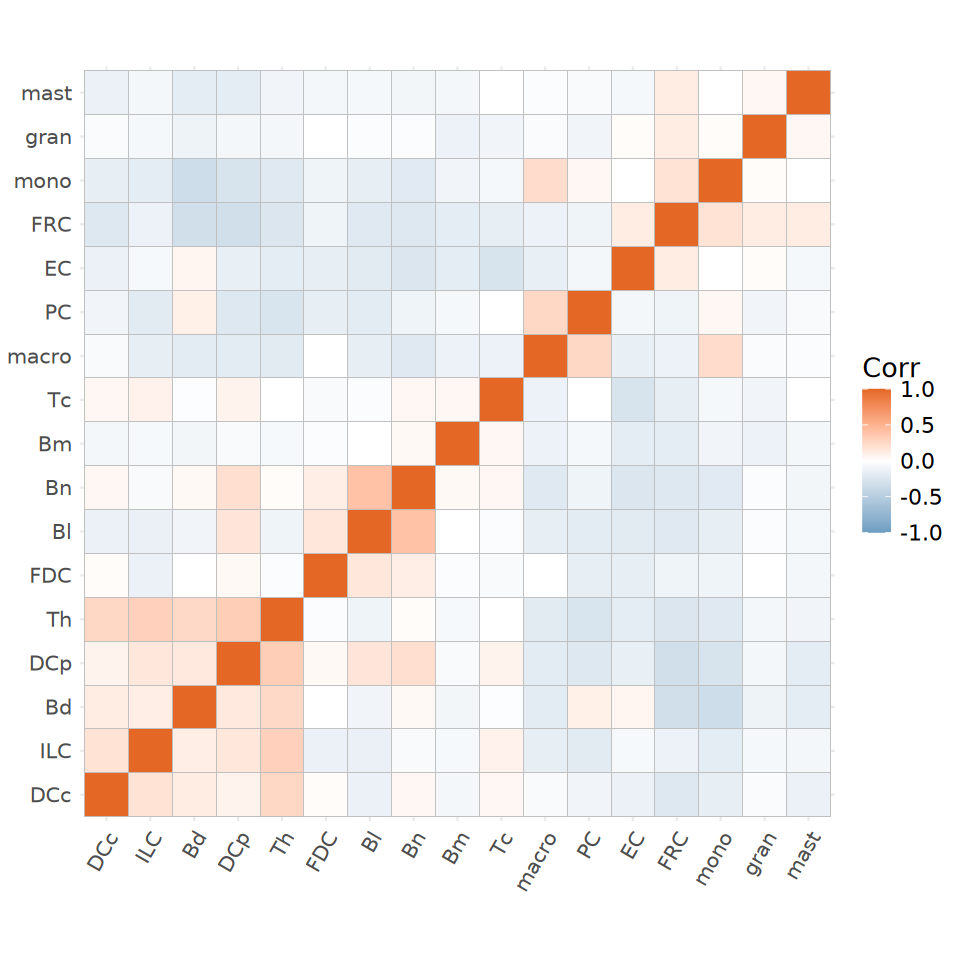

In [10]:
options(repr.plot.width = 8, repr.plot.height = 8, warn = -1)

p <- plotCorrelationMatrix(mat) +
theme(text = element_text(size = 16))
ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/hm_correlation_ln.svg", plot = p, device = svglite, width = 8, height = 8)
print(p)

We can make a graph representing spatial interactions where cell types will have stronger edges between them the more often we find them within the same spot.

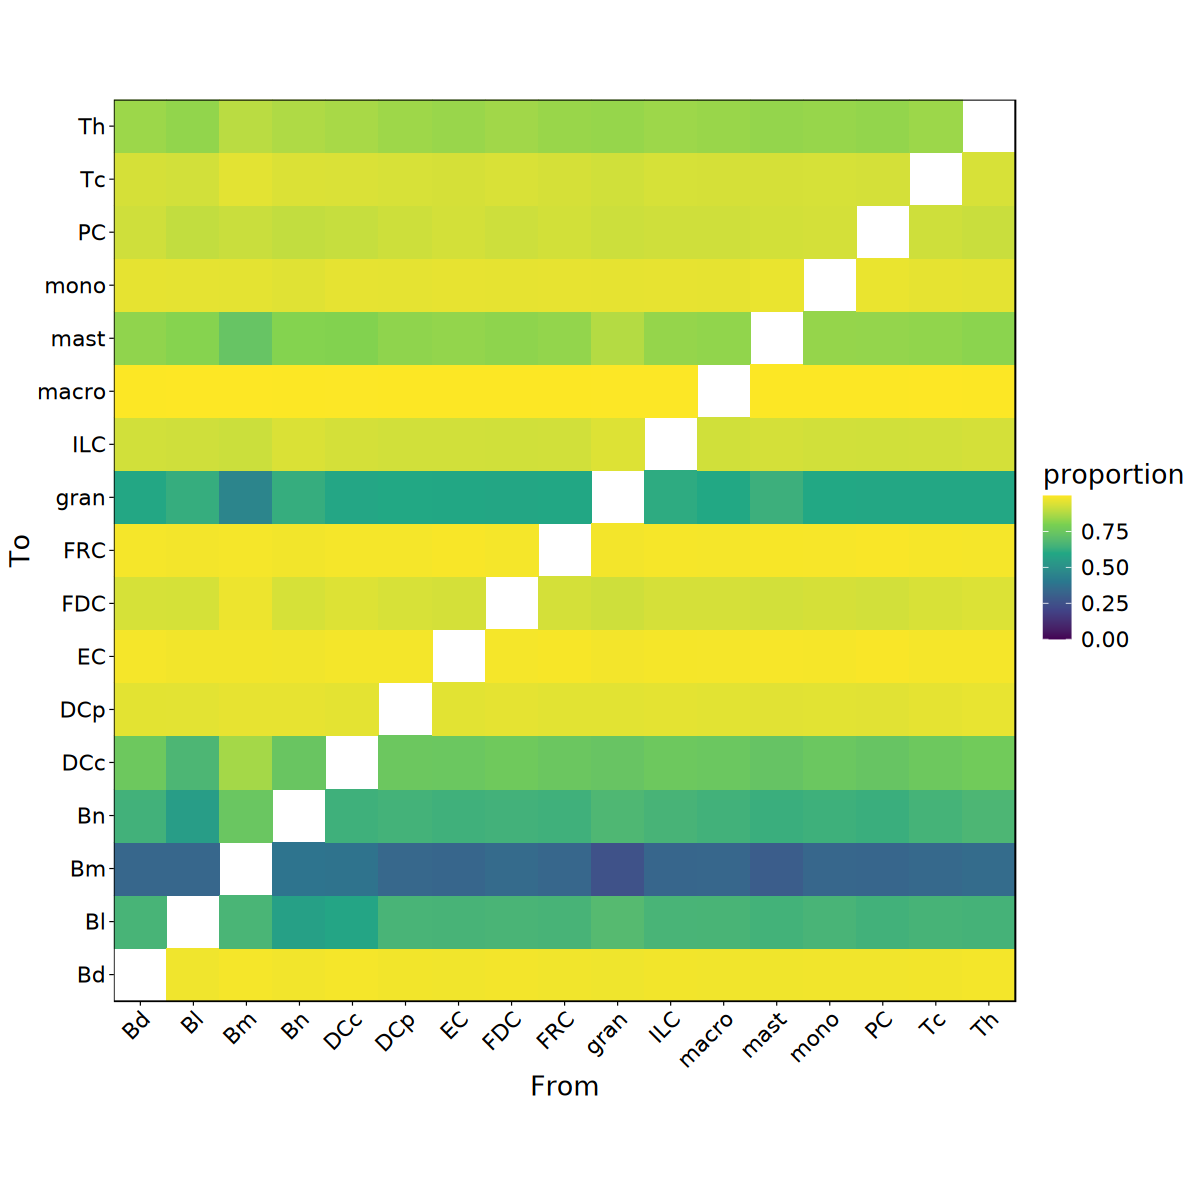

In [11]:
options(repr.plot.width = 10, repr.plot.height = 10, warn = -1)

p <- plotInteractions(mat, which = "heatmap", metric = "prop") +
theme(text = element_text(size = 16))
ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/hm_interactions_ln.svg", plot = p, device = svglite, width = 8, height = 8)
print(p)

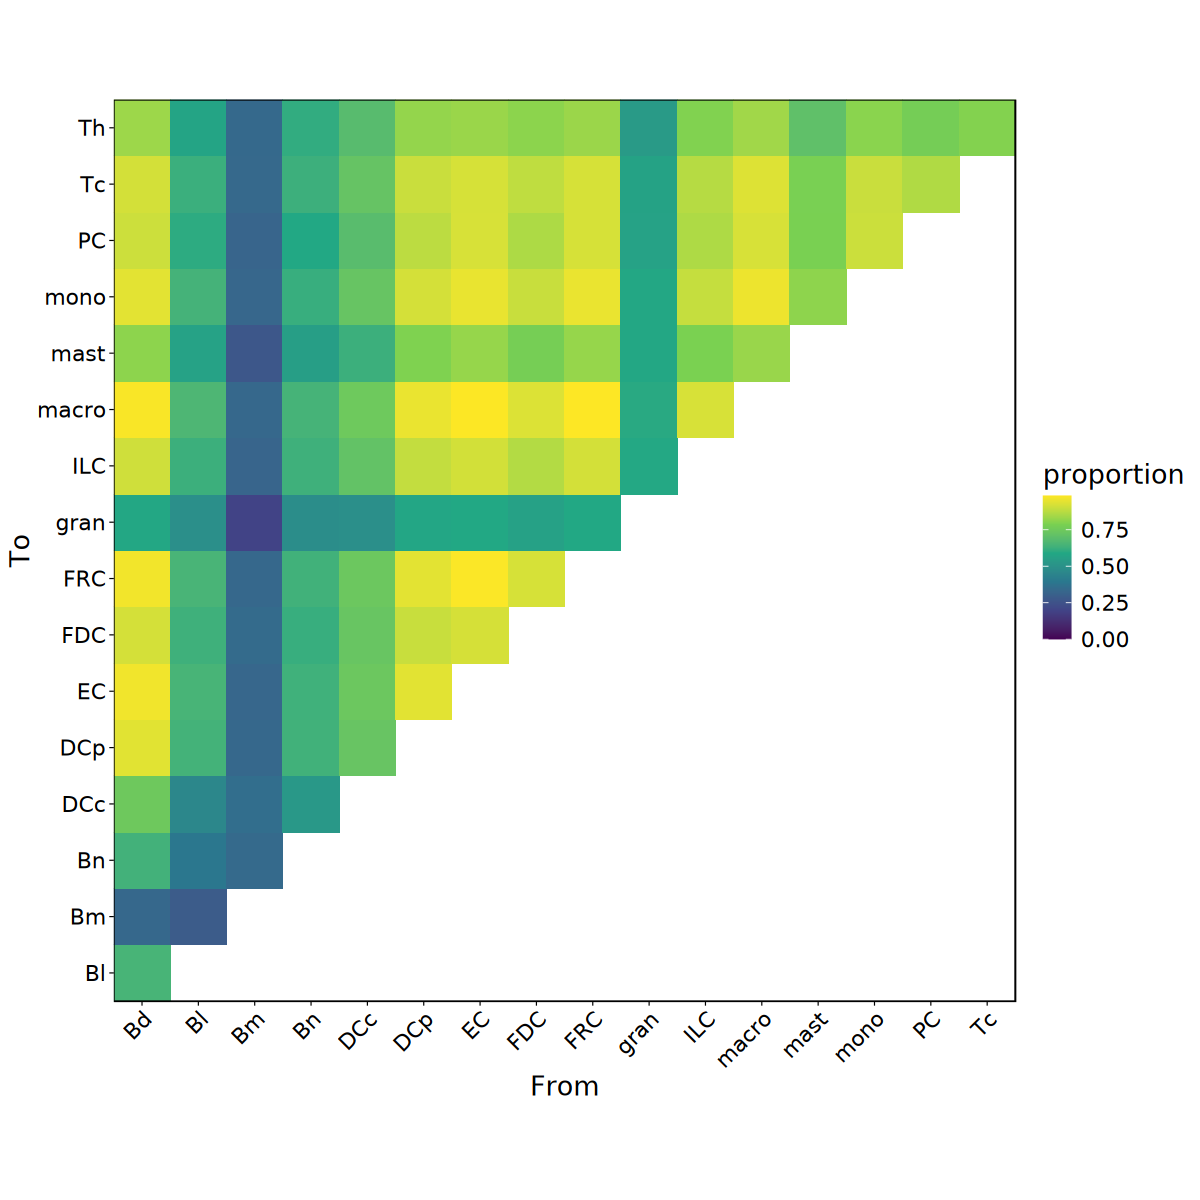

In [12]:
p <- plotInteractions(mat, which = "heatmap", metric = "jaccard") +
theme(text = element_text(size = 16))
ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/hm_interactions_ln.svg", plot = p, device = svglite, width = 8, height = 8)
print(p)

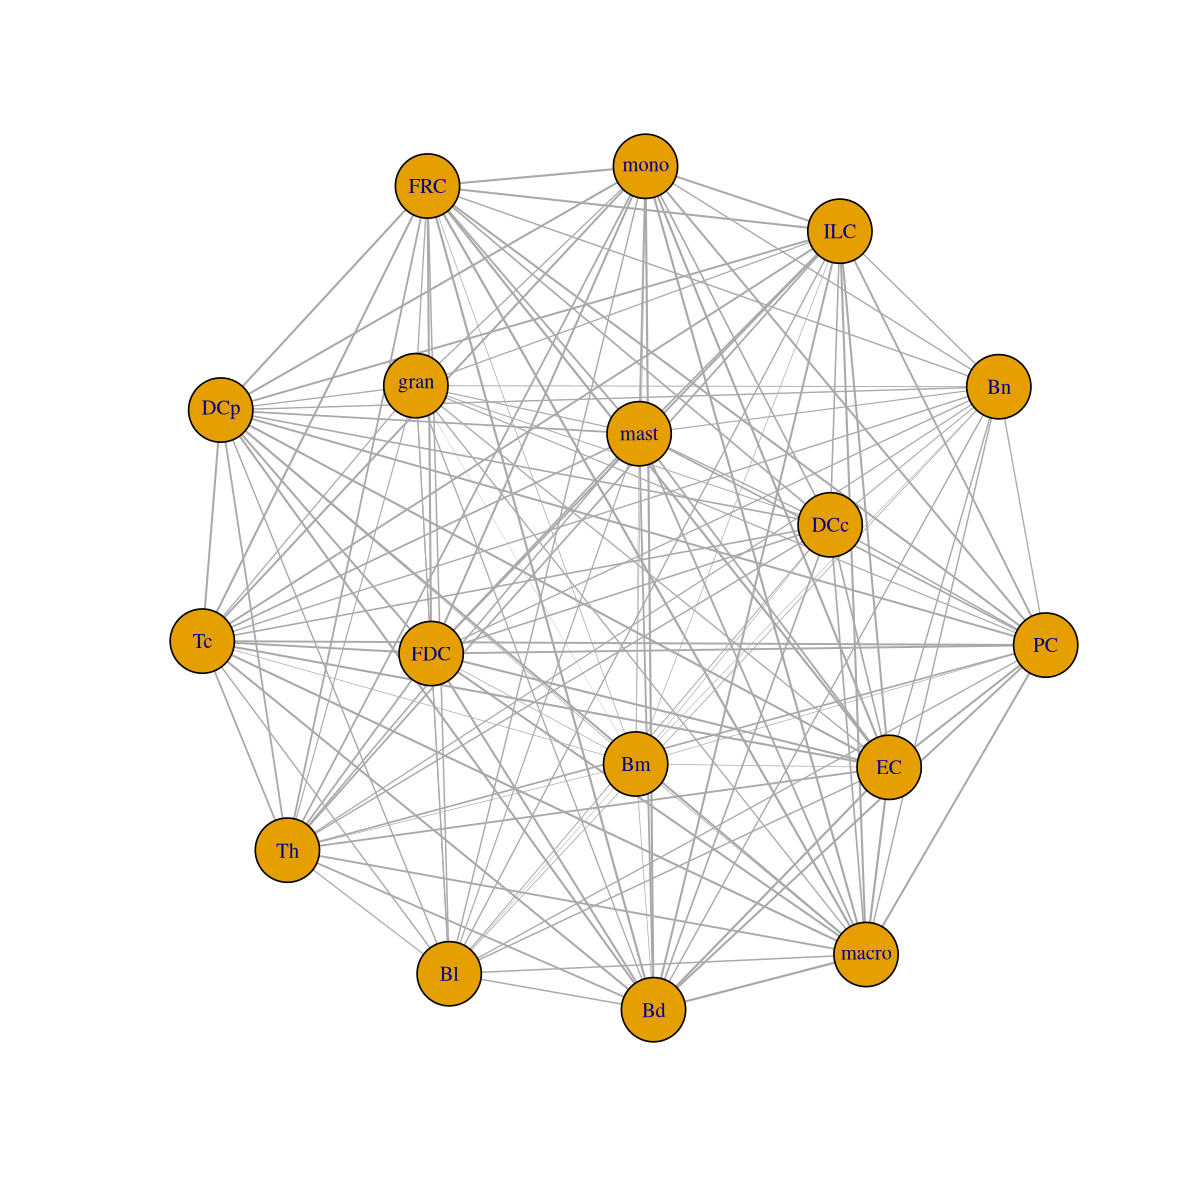

In [13]:
plotInteractions(mat, which = "network")

### Scatterpie

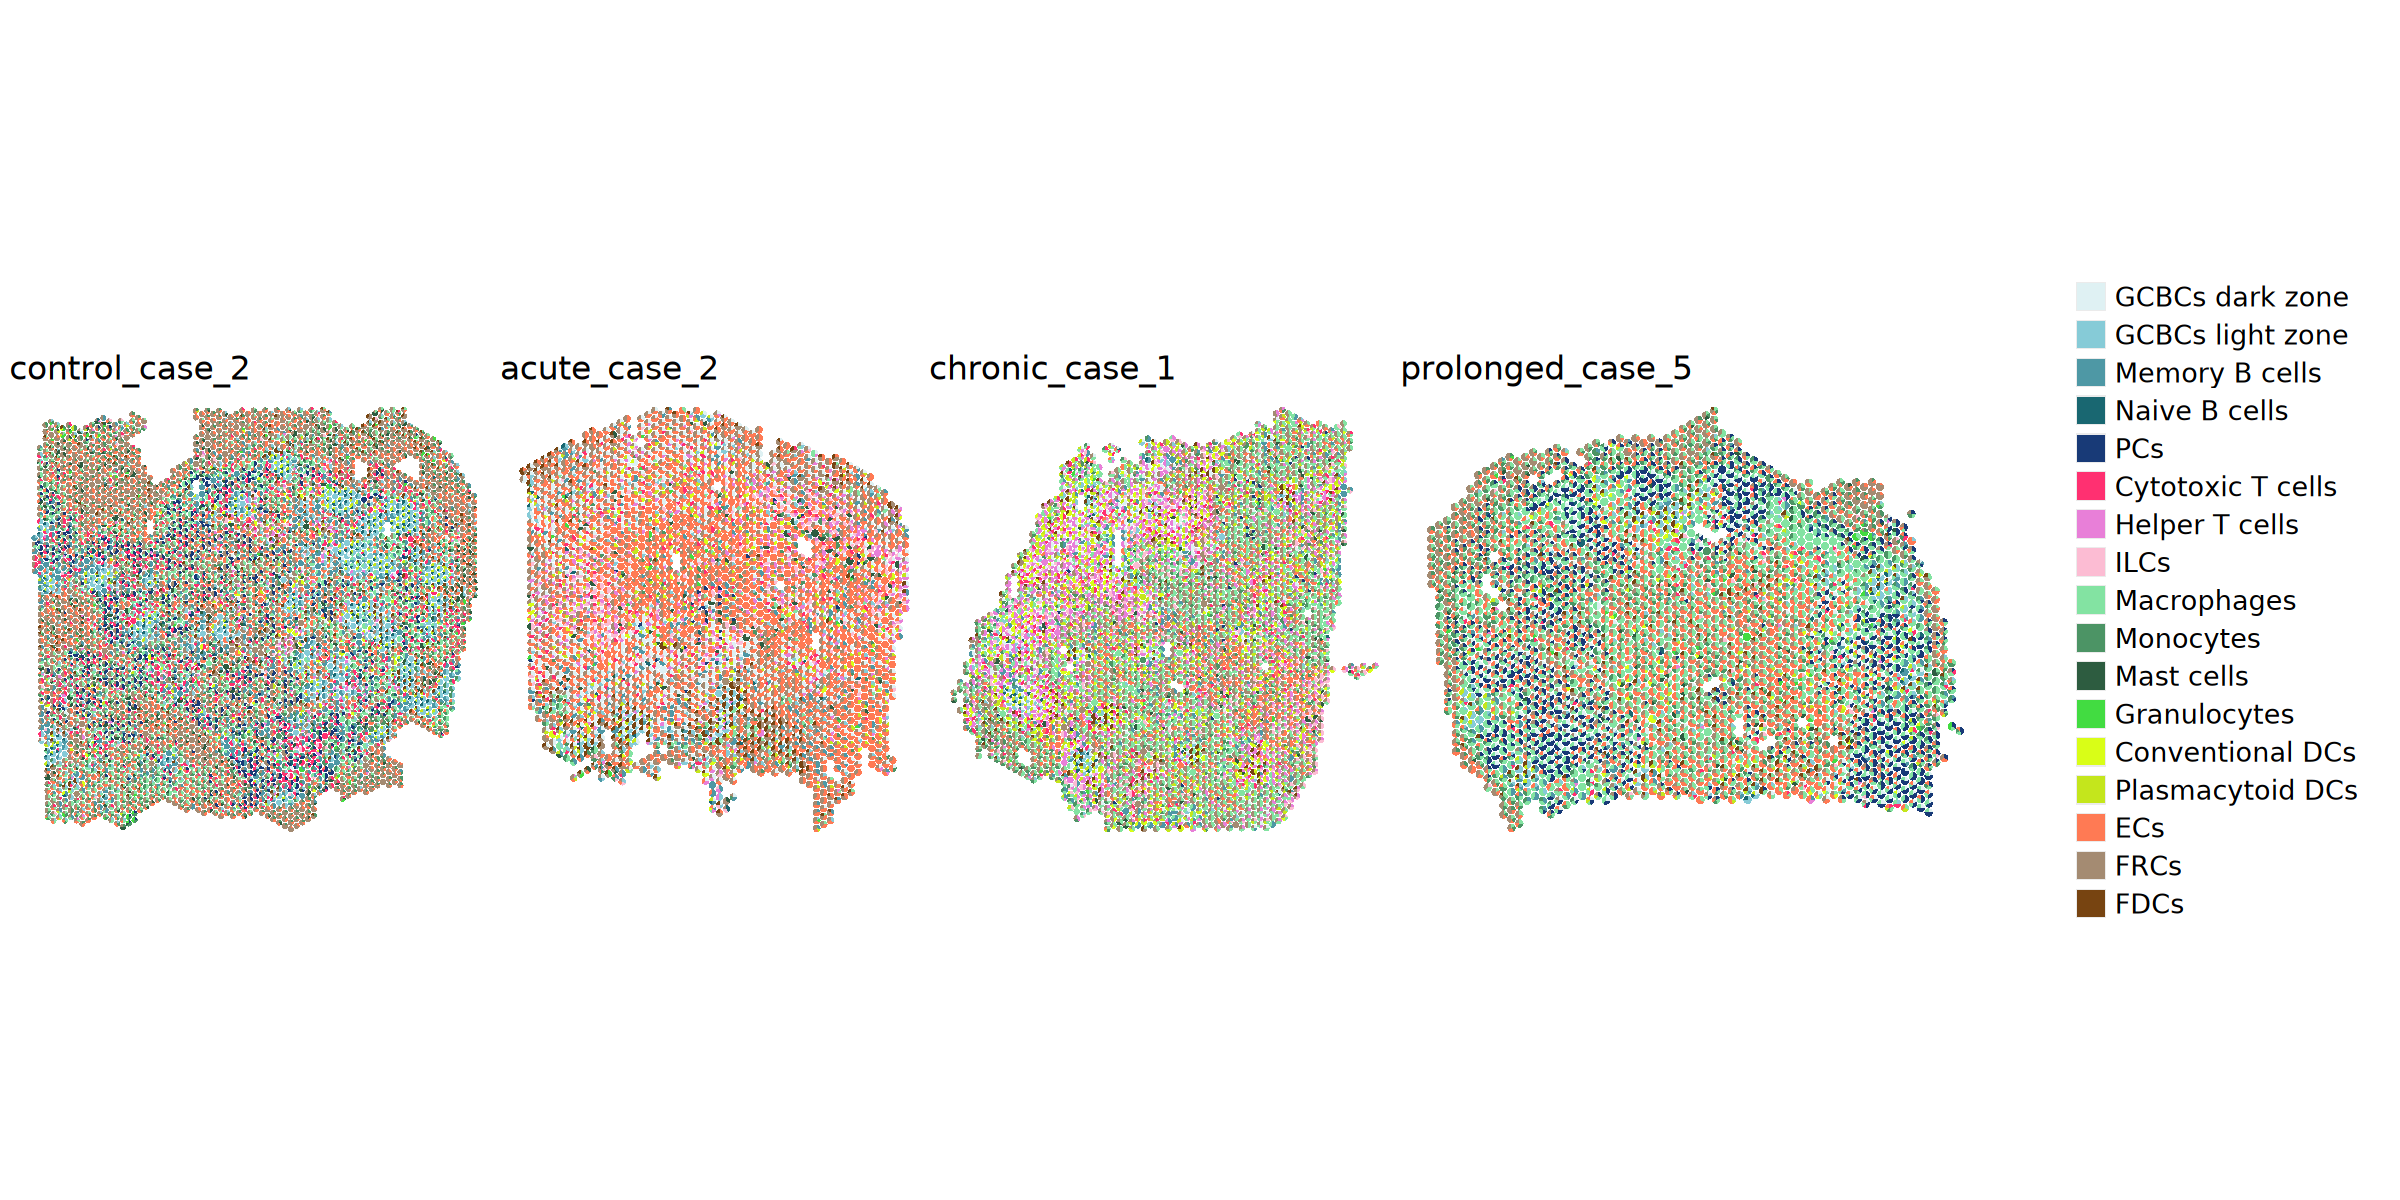

In [10]:
options(repr.plot.width = 20, repr.plot.height = 10, warn = -1)
pie_scales <- c(0.35, 0.5, 0.4, 0.4)
plot_list <- lapply(seq_along(unique(spe$study_id)), function(i) {
    id <- unique(spe$study_id)[i]
    sub_spe <- spe[, spe$study_id == id]
    sub_mat <- mat_filtered[colnames(sub_spe), ] 
    xy <- spatialCoords(sub_spe)
    spatialCoords(sub_spe) <- cbind(pxl_col_in_fullres = max(xy[, 2]) - xy[, 2],
                                    pxl_row_in_fullres = xy[, 1])
    plotSpatialScatterpie(x = sub_spe, y = sub_mat,
                          cell_types = ct, img = FALSE,
                          scatterpie_alpha = 1, pie_scale = pie_scales[i]) +
        ggtitle(id) +
        scale_fill_manual(values = palette, breaks = ct, limits = ct) +
        theme(text = element_text(size = 16),
              legend.position = "none")
})

legend_plot <- ggplot(
    data.frame(ct = factor(ct, levels = ct), x = 1, y = seq_along(ct)),
    aes(x, y, fill = ct)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, labels = labels, name = "") +
    theme(legend.position = "bottom",
          legend.background = element_blank(),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.key = element_rect(color = NA)) +
    guides(fill = guide_legend(ncol = 1))

legend <- cowplot::get_legend(legend_plot)
p <- cowplot::plot_grid(wrap_plots(plot_list, byrow = FALSE, nrow = 1), legend, rel_widths = c(1, 0.2))
ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/spatial_deconv_ln.svg", plot = p, device = svglite, width = 20, height = 16)
print(p)

### Barplot per disease stage

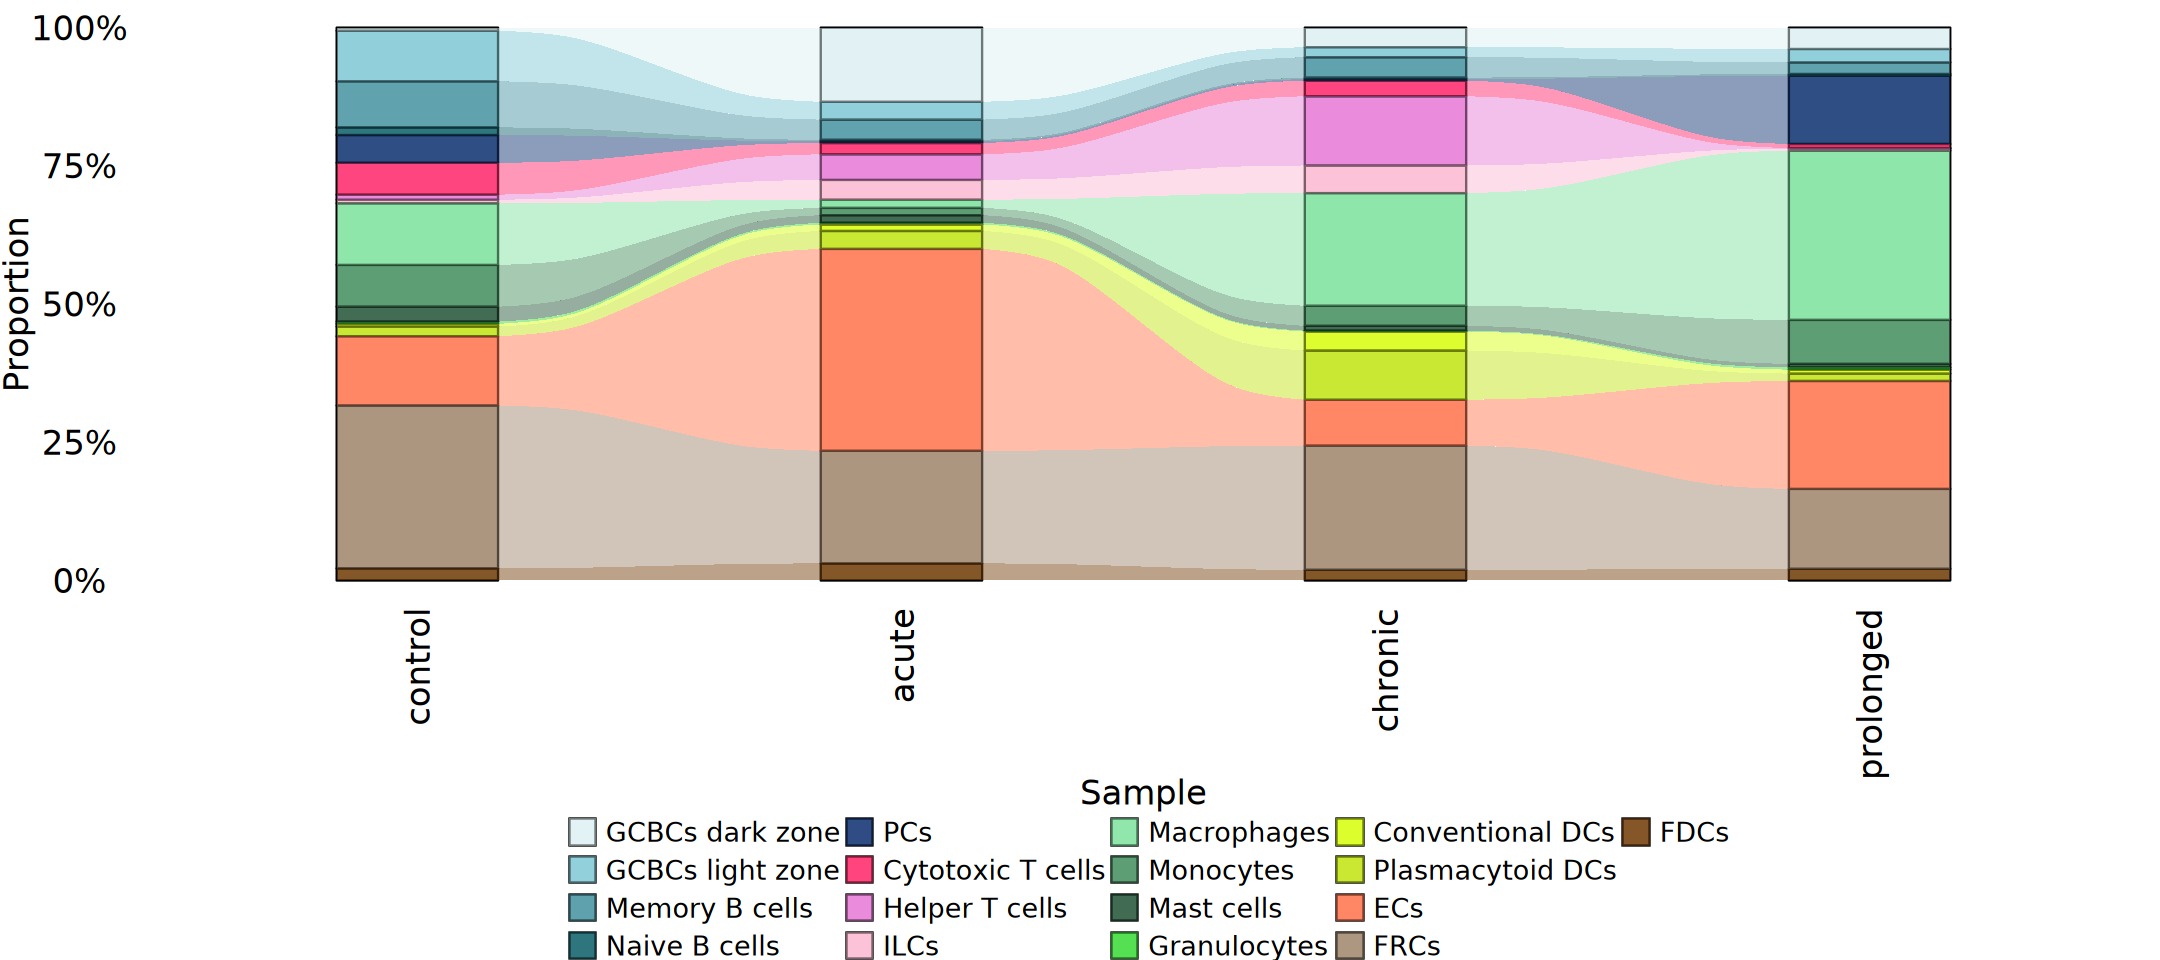

In [11]:
options(repr.plot.width = 18, repr.plot.height = 8, warn = -1)
df <- as.data.frame(mat_filtered)
df$disease_group <- spe$disease_group
p <- df %>%
    pivot_longer(-disease_group, names_to = "cell_type", values_to = "proportion") %>%
    mutate(disease_group = factor(disease_group, levels = c("control", "acute", "chronic", "prolonged")))%>%  
    mutate(cell_type = factor(cell_type, levels = ct)) %>%  
    group_by(disease_group, cell_type) %>%
    summarise(proportion = sum(proportion), .groups = "drop") %>%
    group_by(disease_group) %>%
    mutate(proportion = proportion / sum(proportion)) %>%
    ggplot(aes(x = disease_group, y = proportion, 
               stratum = cell_type, alluvium = cell_type, fill = cell_type)) +
    ggalluvial::geom_stratum(alpha = 0.8) +
    ggalluvial::geom_alluvium(alpha = 0.5) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, labels = labels, name = "") +
    labs(x = "Sample", y = "Proportion", fill = "") +
    theme_void() +
    theme(axis.text = element_text(color = "black", size = 20),
          axis.text.x = element_text(angle = 90, hjust = 1),
          axis.title = element_text(color = "black", size = 20),
          axis.title.y = element_text(angle = 90),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.position = "bottom") +
    guides(fill = guide_legend(nrow = 4))
ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/barplot_case_ln_deconv.svg", plot = p, device = svglite, width = 20, height = 16)
print(p)

### Barplot per donain

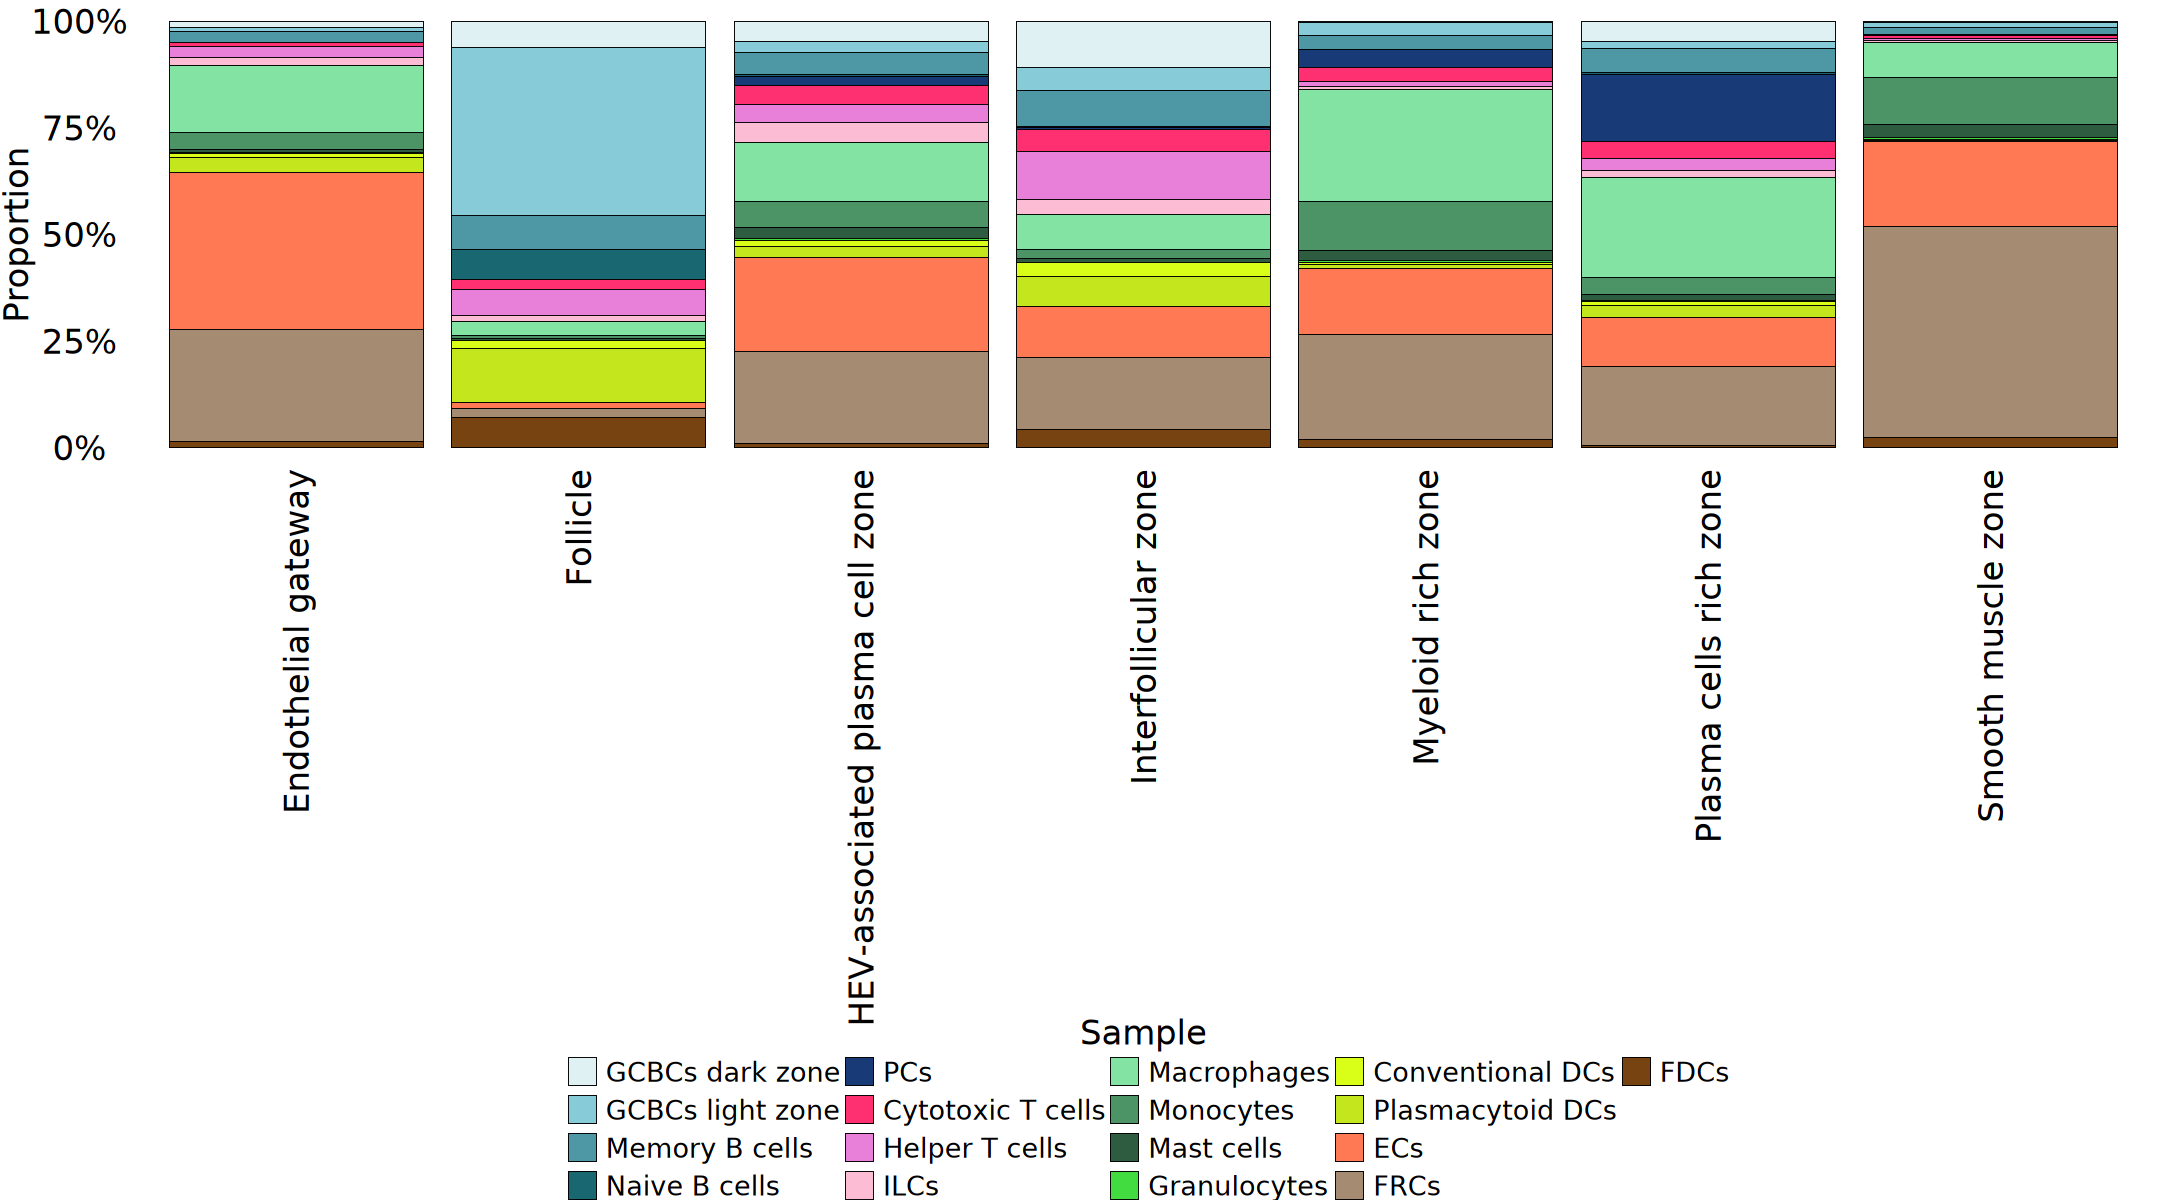

In [12]:
options(repr.plot.width = 18, repr.plot.height = 10, warn = -1)
df <- as.data.frame(mat_filtered)
df$annotation <- spe$annotation
p <- df %>%
    pivot_longer(-annotation, names_to = "cell_type", values_to = "proportion") %>%
    mutate(cell_type = factor(cell_type, levels = ct)) %>%  
    group_by(annotation, cell_type) %>%
    summarise(proportion = sum(proportion), .groups = "drop") %>%
    group_by(annotation) %>%
    mutate(proportion = proportion / sum(proportion)) %>%
    ggplot(aes(x = annotation, y = proportion, fill = cell_type)) +
    geom_bar(stat = "identity", position = "fill", color = "black", linewidth = 0.2) +
    scale_y_continuous(labels = scales::percent_format()) +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, labels = labels, name = "") +
    labs(x = "Sample", y = "Proportion", fill = "") +
    theme_void() +
    theme(axis.text = element_text(color = "black", size = 20),
          axis.text.x = element_text(angle = 90, hjust = 1),
          axis.title = element_text(color = "black", size = 20),
          axis.title.y = element_text(angle = 90),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.position = "bottom") +
    guides(fill = guide_legend(nrow = 4))
ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/barplot_domain_ln_deconv.svg", plot = p, device = svglite, width = 20, height = 16)
print(p)

### Spatial plot of dominant cell-type

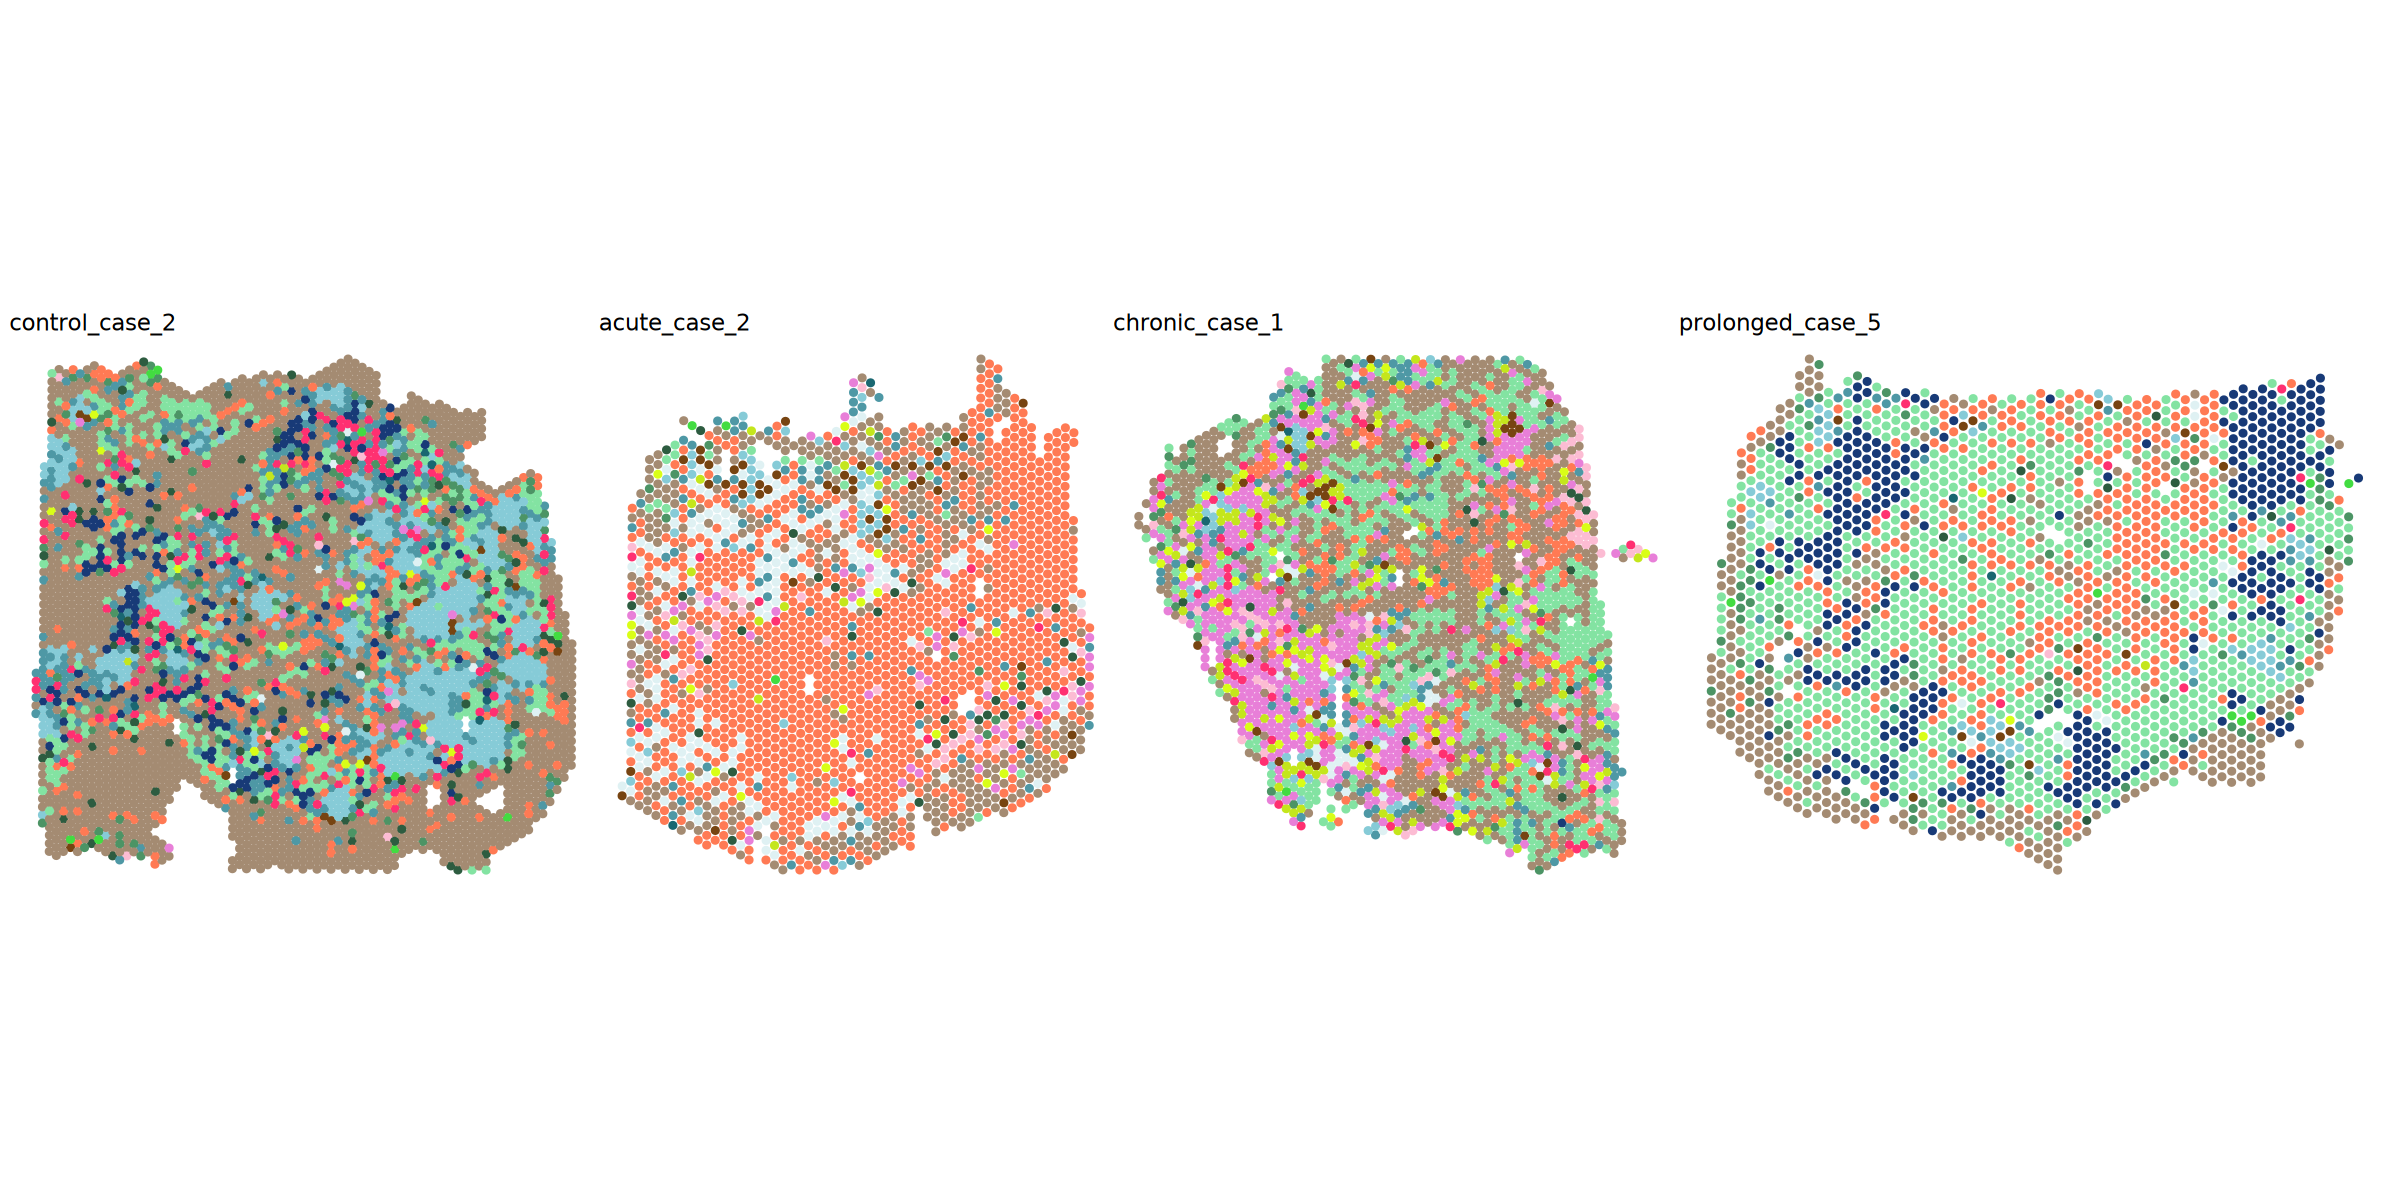

In [13]:
options(repr.plot.width = 20, repr.plot.height = 10, warn = -1)

dominant_list <- lapply(unique(spe$study_id), function(id) {
    sub_spe <- spe[, spe$study_id == id]
    sub_mat <- mat_filtered[colnames(sub_spe), ]
    
    dominant_ct <- colnames(sub_mat)[apply(sub_mat, 1, which.max)]
    sub_spe$dominant_ct <- dominant_ct
    
    xy <- spatialCoords(sub_spe)
    sub_spe$x <- xy[, 1]
    sub_spe$y <- xy[, 2]
    
    df <- data.frame(x = sub_spe$x, y = sub_spe$y,
                     dominant_ct = factor(sub_spe$dominant_ct, levels = names(palette)))
    
    ggplot(df, aes(x, y, color = dominant_ct)) +
    geom_point() +
    scale_color_manual(values = palette, name = "Cell Type", drop = TRUE) +
    coord_fixed() +
    theme_void() +
    ggtitle(id) +
    theme(legend.position = "none")
}) 

wrap_plots(dominant_list, byrow = FALSE, nrow = 1) +
    plot_layout(guides = "collect")

# Save data

In [19]:
out_dir <- "~/SP-COVID/visium/1-deconvolution/out"

"{out_dir}/mat_filtered_ln.rds" %>%
    glue::glue() %>%
  saveRDS(object = mat_filtered, file = .)

# Session information

In [20]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] svglite_2.2.2               NMF_0.28                   
 [3] cluster_2.1.8.2             rngtools_1.5.2             
 [5] registry_0.5-1              SPOTlight_1.14.0           
 [7] ggspavis_